In [1]:
%cd ../

/Users/paulb/Desktop/code/research/babi


In [115]:
import os
import pandas as pd
import numpy as np
import data.constants
from data import plotting
import models.constants
from models import processing, constants
import matplotlib.pyplot as plt

import importlib
importlib.reload(data.constants)
importlib.reload(models.constants)
importlib.reload(plotting)
importlib.reload(processing)

<module 'models.processing' from '/Users/paulb/Desktop/code/research/babi/models/processing.py'>

In [3]:
training_set, (set_mean, set_std) = processing.get_training_dataset(with_pruning=True)
train_percentage = 0.8
train, val = np.split(training_set, [int(train_percentage * len(training_set))])
print(f"Training set shape: {train.shape}, Validation set shape: {val.shape}")

Constraint 'min_amplitude' failures: 92044
Constraint 'plateau_slope_tolerance' failures: 122982
Constraint 'plateau_vertical_tolerance' failures: 3377
Constraint 'min_length' failures: 8640
Constraint 'max_units_from_zero' failures: 478
Constraint 'unit_max_amplitude' failures: 4825
Constraint 'mean_max_amplitude_error_percentage' failures: 33
Min unit length: 0.55 seconds.
Max unit length: 1.50 seconds.
Mean unit length: 1.12 seconds.
Total unit length: 33.34 minutes.
Extracted 1778 units for training dataset.
After pruning, 1620 units remain for training dataset.
Training set shape: (1296, 20, 1), Validation set shape: (324, 20, 1)


In [4]:
from models import autoencoder

ae = autoencoder.build()

history = ae.fit(
    train, train,
    validation_data=(val, val),
    epochs=100,
    batch_size=32,
    shuffle=True
)

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 297.2167 - val_loss: 309.1702
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 252.8650 - val_loss: 216.4530
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 149.2789 - val_loss: 104.9319
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 76.1190 - val_loss: 48.7190
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 36.0729 - val_loss: 20.6887
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 20.1266 - val_loss: 14.9847
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 17.7220 - val_loss: 14.6453
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 16.9518 - val_loss: 13.7887
Epoch 9/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 16.1363 - val_loss: 13.0676
Epoch 10/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 15.3587 - val_loss: 12.3453
Epoch 11/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 14.5847 - val_loss: 11.6396
Epoch 12/100
41/41 ━━━━━━━━━━━━━━━━

In [5]:
sample_path = os.listdir(os.path.join(data.constants.preprocessed_data_dir, "capnostream"))[1]
sample: pd.DataFrame = pd.read_pickle(os.path.join(data.constants.preprocessed_data_dir, "capnostream", sample_path))
print(sample.attrs)
signal = sample["co2_wave"].to_numpy()

{'Patient ID': 'BB_003_1', 'Patient Type': 'Infant/Neonatal', 'Report Generation Time': 'Mar 10,25  08:12:56 AM', 'Date': 'Mar 10,25'}


In [66]:
from models.processing import augmentation
from numpy.lib.stride_tricks import sliding_window_view

units = sliding_window_view(signal, (constants.unit_length, ))
units = np.array([augmentation.stretch_to_unit_length(unit)[0] for unit in units])

In [104]:
threshold = autoencoder.calculate_threshold(ae, val, percentile=95)
print(f"Calculated threshold: {threshold}")
predict = autoencoder.predictor(ae, threshold)
batch_predict = autoencoder.batch_predictor(ae, threshold)

Calculated threshold: 23.578303901254287


In [124]:
from itertools import compress

recons, errors, labels = batch_predict(units)
predictions: list[tuple[np.ndarray, np.ndarray, np.floating, np.bool]] = list(zip(units, recons, errors, labels))
valid_predictions = list(compress(predictions, labels))
invalid_predictions = list(compress(predictions, ~labels))

print(f"Total units: {len(predictions)}")
print(f"Valid units: {len(valid_predictions)} ({round(len(valid_predictions) / len(predictions) * 100, 2)}%)")
print(f"Invalid units: {len(invalid_predictions)} ({round(len(invalid_predictions) / len(predictions) * 100, 2)}%)")

Total units: 40386
Valid units: 5879 (14.56%)
Invalid units: 34507 (85.44%)



----- VALID SAMPLES -----

Valid Sample 1 (Index 1918): Valid | 6.33 (-17.25)


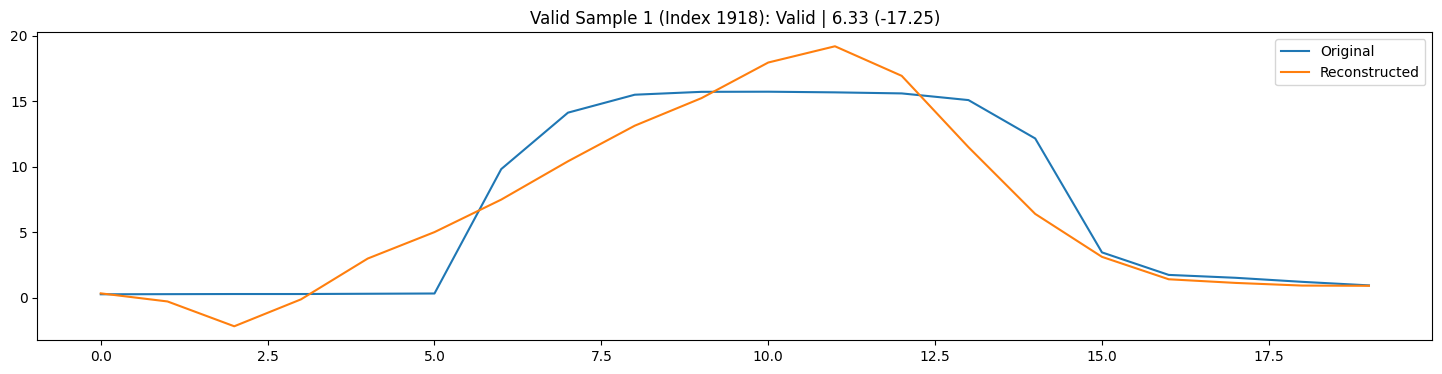

Valid Sample 2 (Index 1824): Valid | 14.38 (-9.2)


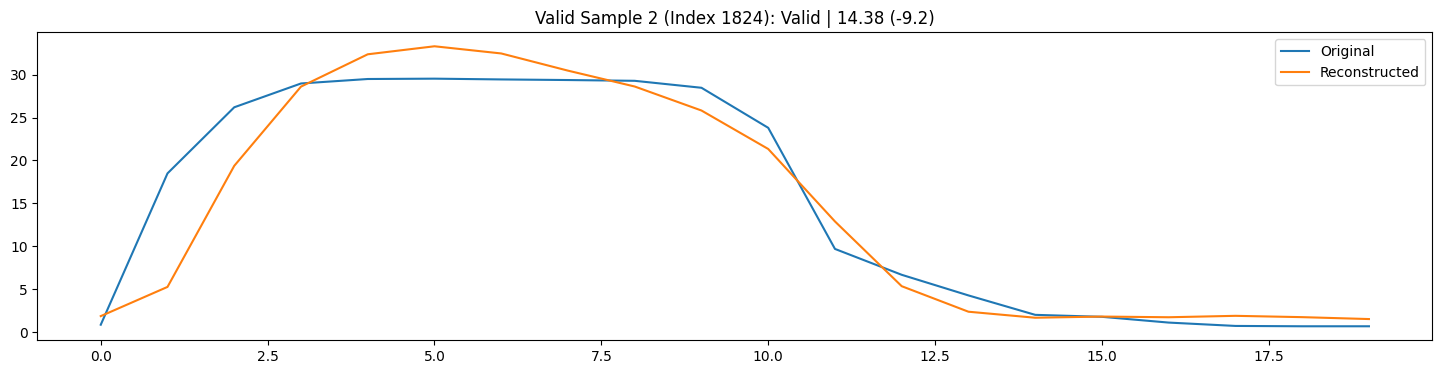

Valid Sample 3 (Index 3753): Valid | 6.14 (-17.44)


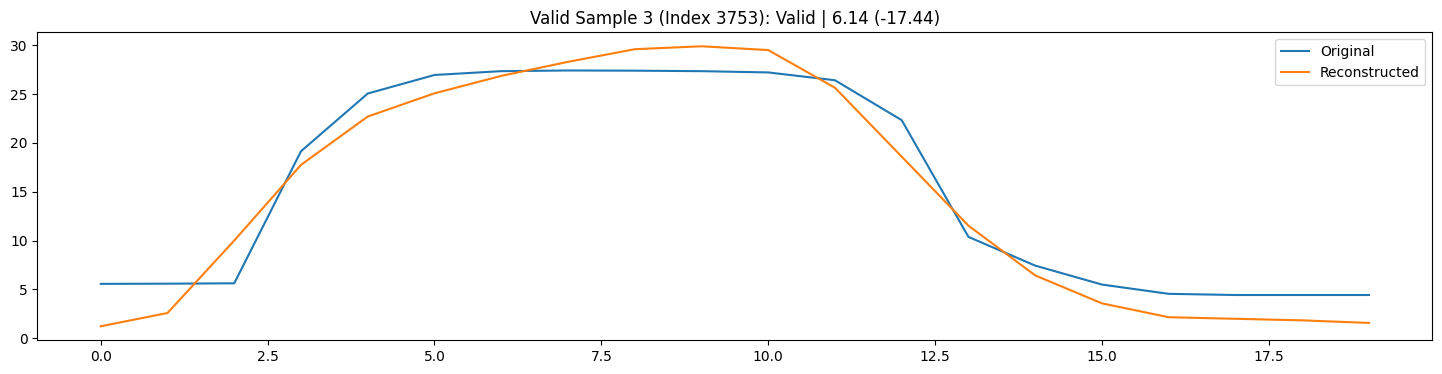


-----INVALID SAMPLES -----

Invalid Sample 1 (Index 27802): Invalid | 135.04 (111.46)


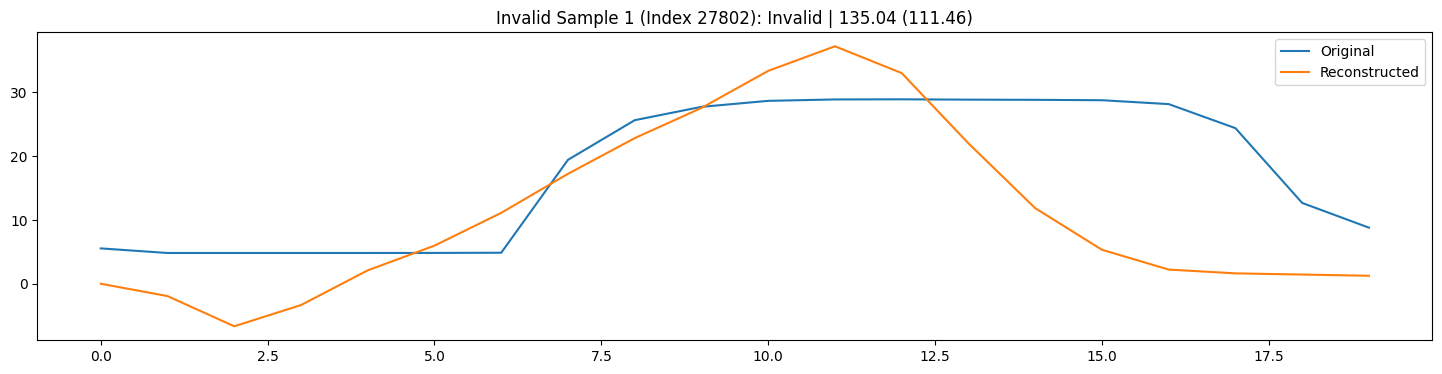

Invalid Sample 2 (Index 23477): Invalid | 122.13 (98.55)


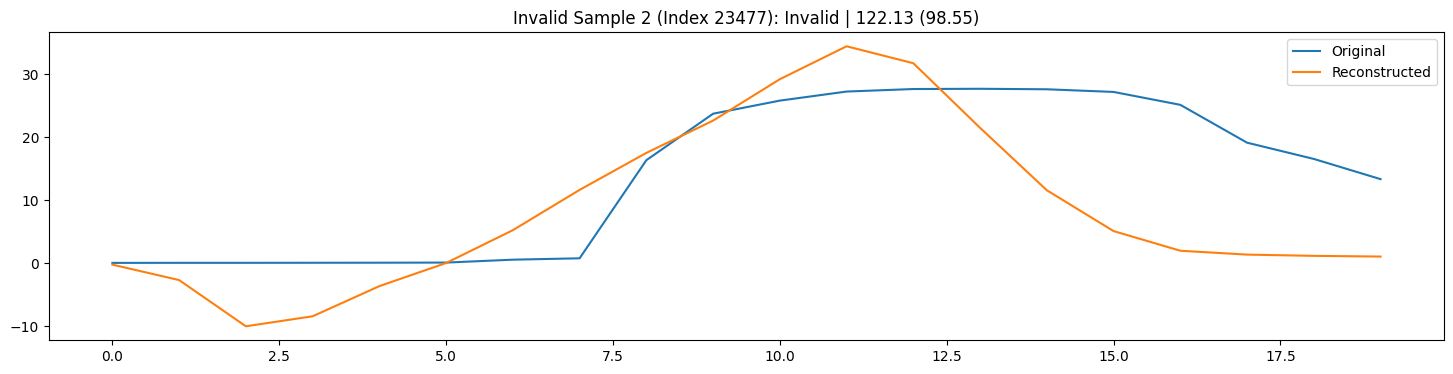

Invalid Sample 3 (Index 17417): Invalid | 89.24 (65.66)


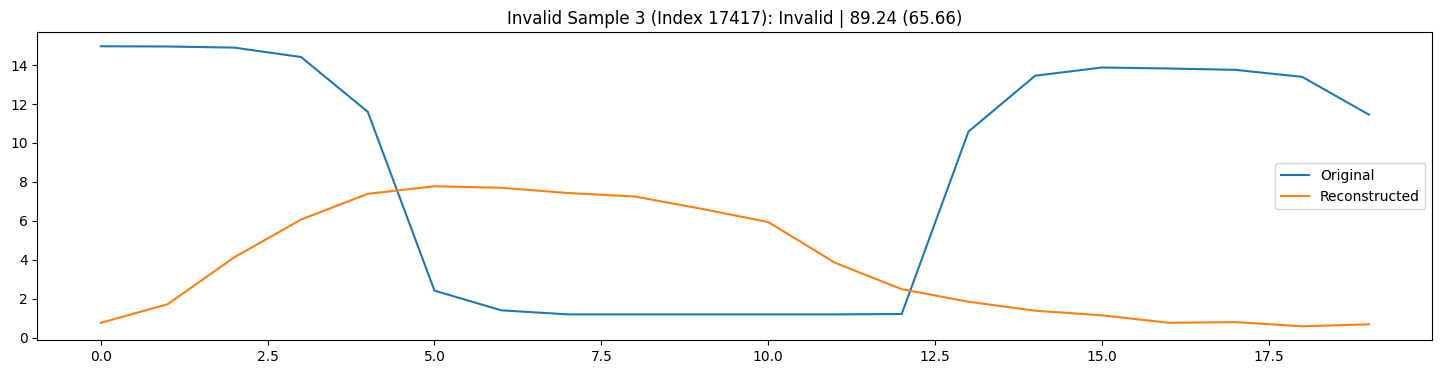

In [ ]:
print("\n----- VALID SAMPLES -----\n")

n_valid_predictions = 3
for i in range(n_valid_predictions):
    index = np.random.randint(0, len(valid_predictions))
    original, recon, error, valid = valid_predictions[index]
    title = f'Valid Sample {i+1} (Index {index}) | {round(error, 2)} ({round(error - threshold, 2)})'
    print(title)
    plotting.dual(original, recon, title=title)

print("\n-----INVALID SAMPLES -----\n")

n_invalid_predictions = 3
for i in range(n_invalid_predictions):
    index = np.random.randint(0, len(invalid_predictions))
    original, recon, error, valid = invalid_predictions[index]
    title = f'Invalid Sample {i+1} (Index {index}) | {round(error, 2)} ({round(error - threshold, 2)})'
    print(title)
    plotting.dual(original, recon, title=title)


----- BEST VALID SAMPLES -----

Valid Sample 1 | 0.11 (-23.47)


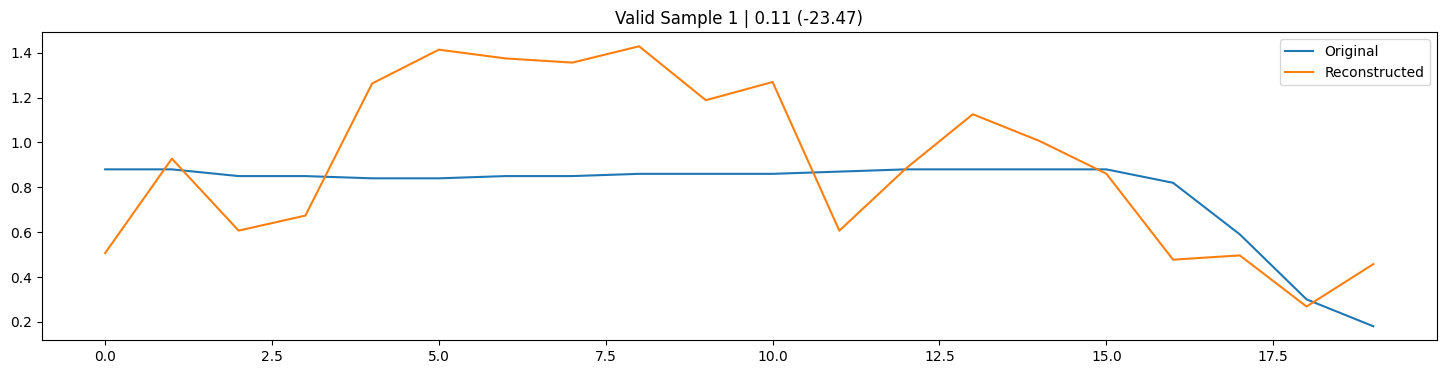

Valid Sample 2 | 0.11 (-23.47)


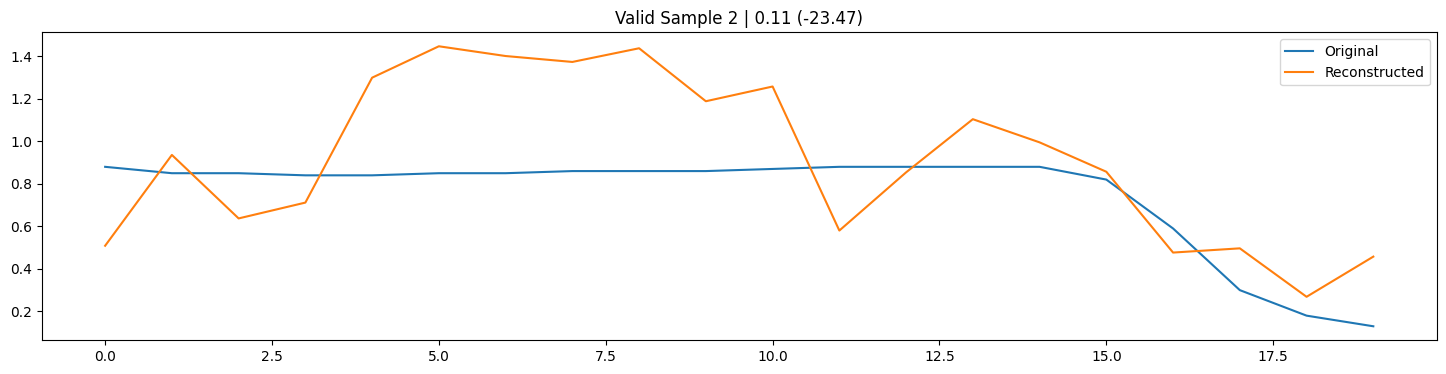

Valid Sample 3 | 0.12 (-23.46)


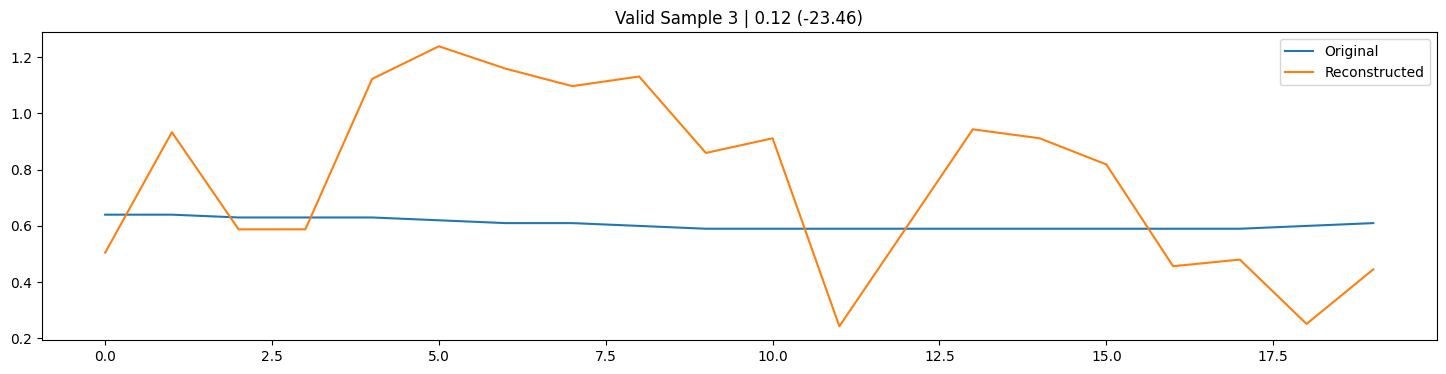


----- WORST VALID SAMPLES -----

Valid Sample 1 | 23.58 (-0.0)


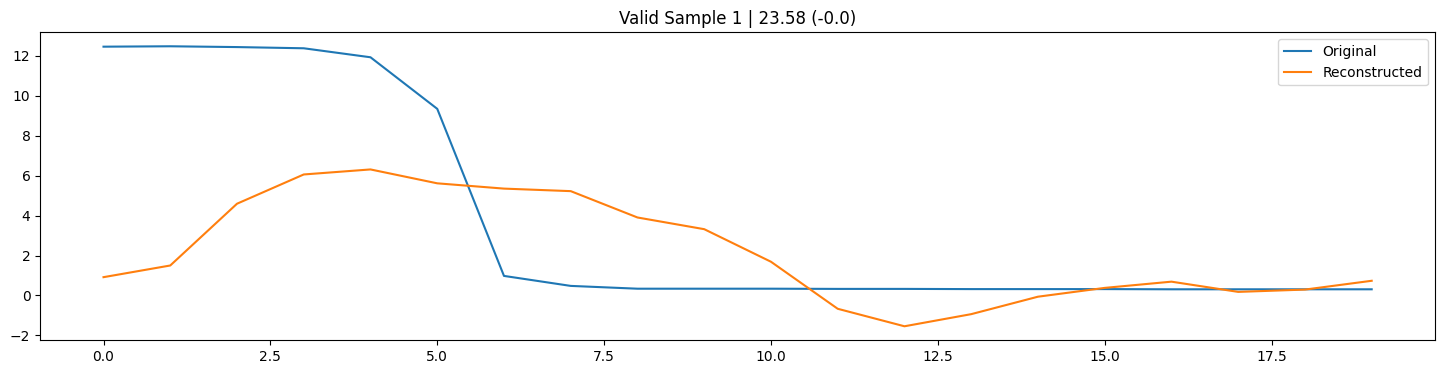

Valid Sample 2 | 23.58 (-0.0)


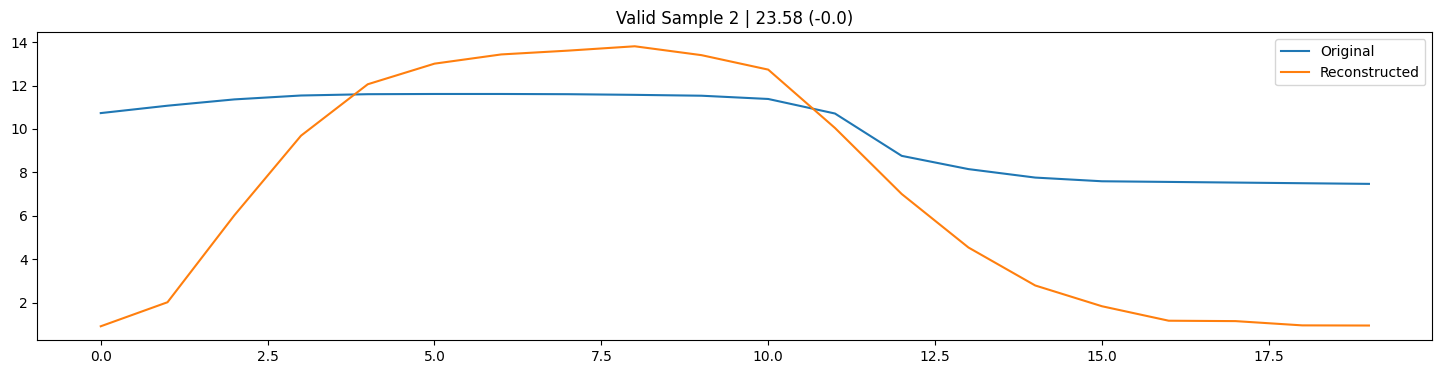

Valid Sample 3 | 23.57 (-0.01)


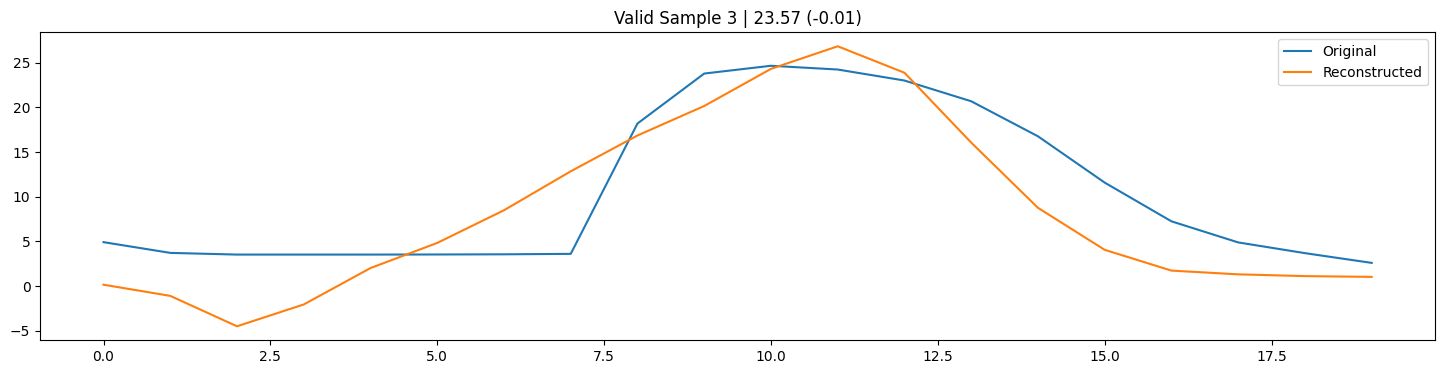

In [ ]:
print("\n----- BEST VALID SAMPLES -----\n")

n_best_valid = 3
best_valid = sorted(valid_predictions, key=lambda x: x[2])
for i in range(n_best_valid):
    original, recon, error, valid = best_valid[i]
    title = f'Valid Sample {i+1} | {round(error, 2)} ({round(error - threshold, 2)})'
    print(title)
    plotting.dual(original, recon, title=title)

print("\n----- WORST VALID SAMPLES -----\n")

n_worst_valid = 3
worst_valid = sorted(valid_predictions, key=lambda x: x[2], reverse=True)
for i in range(n_worst_valid):
    original, recon, error, valid = worst_valid[i]
    title = f'Valid Sample {i+1} | {round(error, 2)} ({round(error - threshold, 2)})'
    print(title)
    plotting.dual(original, recon, title=title)

# todo: should penalize based on cosine similarity